In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./MNRAS.mplstyle')

import os, glob
from pathlib import Path

import h5py

$\delta \ln Y = \ln Y - \langle\ln Y | M \rangle $
where $\langle\ln Y | M \rangle$ is obtained by KLLR.

Same for $\delta \ln \Sigma_g$, and so on.

# Note: always $\delta \ln Y = \ln Y - \langle\ln Y | \ln(M_{\rm 500c}) \rangle$

In [2]:
#-------------------- Load correlation data --------------------#

DATA_BASE = Path("corr_scat/")

########################### ln(Ycyl) -- \Sigma_g ###########################
# Sigma_g  :      d_proj = 300
# Ycyl(<= R500c): d_proj = 300
corr_Ysigg = DATA_BASE / "corrcoef_lnYcyl_sigg_linear_20rps_Yproj300_siggproj300.h5"
with h5py.File(corr_Ysigg, "r") as f:
    std_corrcoef_lnY_sigg  = f['std_corrcoef'][:]
    mean_corrcoef_lnY_sigg = f['mean_corrcoef'][:]
    rp_bins_Ysigg = f['rp_bins'][:]


########################### ln(Ycyl(<R500c)) -- ln Sigma ###########################
# proj_depth_all = [60, 90, 180, 300] # cMpc/h for lensing measurements (4)   @d_proj
dproj_idx = 3

corr_Y500c_Sig = DATA_BASE / "corrcoef_Y500c_Sigma_20rps_4cyl_4proj.h5"
with h5py.File(corr_Y500c_Sig, "r") as f:
    err_corrcoef_Y500c_Sig  = f['err_corrcoef'][:]
    mean_corrcoef_Y500c_Sig = f['mean_corrcoef'][:]
    rp_bins_Y500c_Sig = f['rp_bins'][:]

# print(corr_Y500c_Sig, "datasets →", list(f.keys()))

# print(20*'-','Y500c_Sig',20*'-')
std_corrcoef_lnY_lnSig  = err_corrcoef_Y500c_Sig [:, dproj_idx, dproj_idx]
mean_corrcoef_lnY_lnSig = mean_corrcoef_Y500c_Sig[:, dproj_idx, dproj_idx]



########################### ln Ycyl(<=R500c) (w/o noise) -- ln cy (w/o noise) ############################

corr_Yy = DATA_BASE / "corrcoef_lnY500c_lncy_20rps_proj300.h5"
with h5py.File(corr_Yy, "r") as f:
    std_corrcoef_lnY_lncy  = f['std_corrcoef'][:]
    mean_corrcoef_lnY_lncy = f['mean_corrcoef'][:]
    rp_bins_lnY_lncy = f['rp_bins'][:]
    



In [3]:
def load_scatter_hdf5(infile):
    """
    Load scatter-vs-rp results and metadata from an HDF5 file.

    Returns
    -------
    data : dict
        Nested dictionary with keys:
        - 'rp_bins'
        - 'meta'
        - 'scatter'
    """
    data = {
        "rp_bins": None,
        "meta": {},
        "scatter": {}
    }

    with h5py.File(infile, "r") as h5:
        # rp
        data["rp_bins"] = h5["rp_bins"][:]

        # meta attrs
        if "meta" in h5:
            meta = h5["meta"]

            for key, val in meta.attrs.items():
                data["meta"][key] = val

            for key in meta.keys():
                arr = meta[key][:]
                if arr.dtype.kind == "S":
                    arr = arr.astype(str)
                data["meta"][key] = arr

        # scatter groups
        if "scatter" in h5:
            scat = h5["scatter"]

            for obs_name in scat.keys():
                g = scat[obs_name]

                data["scatter"][obs_name] = {
                    "mean": g["mean"][:],
                    "err": g["err"][:],
                    "attrs": dict(g.attrs)
                }

    return data

scatfile  = DATA_BASE /"scatter_kllr_rpresid_20rps_all_halos_proj300_add_sigg.h5"


dat = load_scatter_hdf5(scatfile)

rp = dat["rp_bins"]


# scat_DS_mean = dat["scatter"]["DeltaSigma"]["mean"]
# scat_DS_err  = dat["scatter"]["DeltaSigma"]["err"]

scat_lnSig_mean = dat["scatter"]["lnSigma"]["mean"]  ### mean of residual
scat_lnSig_err  = dat["scatter"]["lnSigma"]["err"]   ###  std of residual

scat_lny_mean = dat["scatter"]["lnycyl"]["mean"]
scat_lny_err  = dat["scatter"]["lnycyl"]["err"]


# scat_lny_so_bl_mean = dat["scatter"]["lnycyl_so_baseline"]["mean"]
# scat_lny_so_bl_err  = dat["scatter"]["lnycyl_so_baseline"]["err"]

scat_sigg_hd_mean = dat["scatter"]["sigg_hd"]["mean"]
scat_sigg_hd_err = dat["scatter"]["sigg_hd"]["err"]

print("rp shape:", rp.shape)
print("cy_true mean shape:", scat_lny_mean.shape)
print("lnSigma mean shape:", scat_lnSig_mean.shape)
print("sigg_hd mean shape:", scat_sigg_hd_mean.shape)


rp shape: (20,)
cy_true mean shape: (20,)
lnSigma mean shape: (20,)
sigg_hd mean shape: (20,)


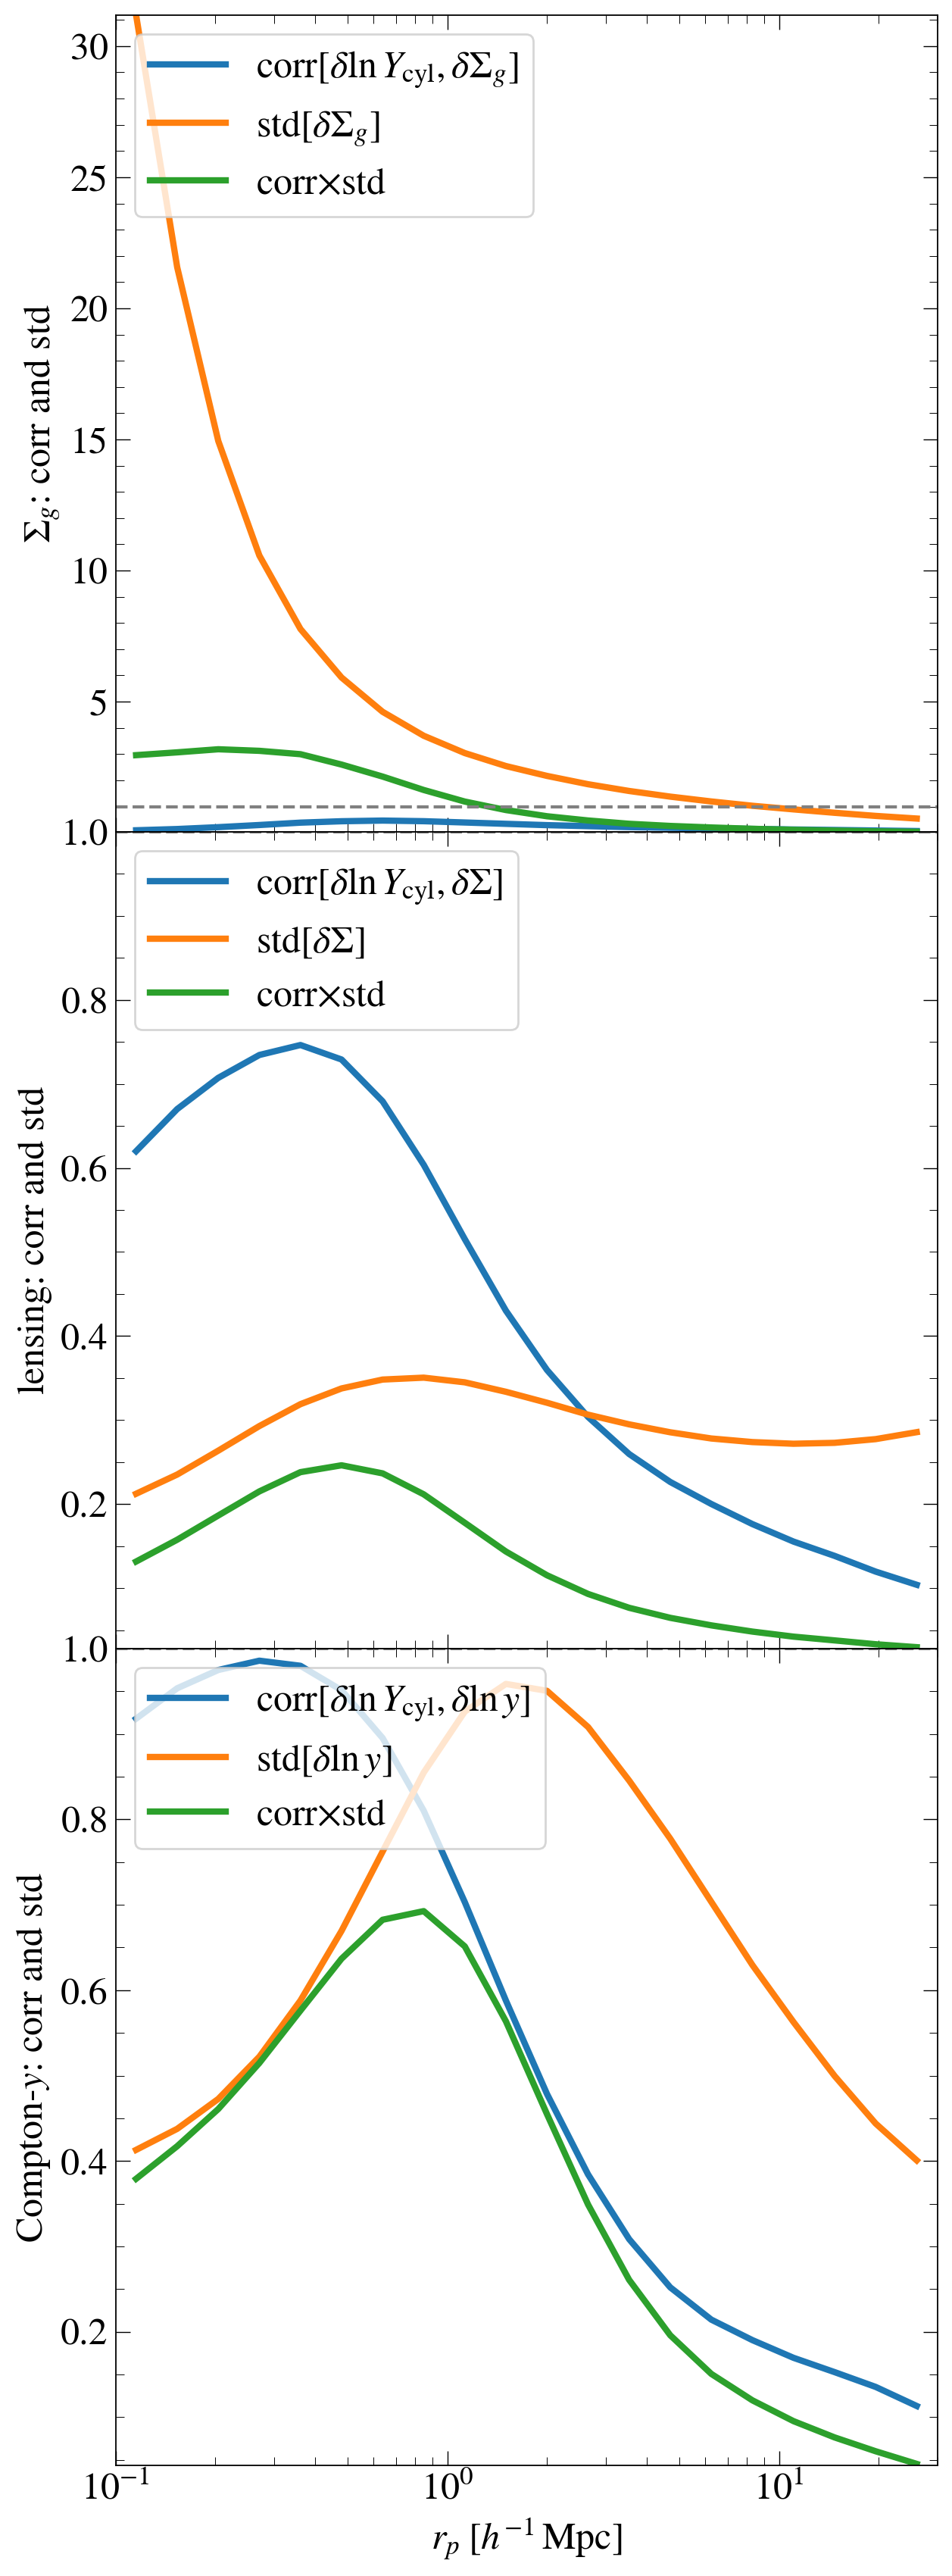

In [4]:
# using Ycyl (no noise) only
### use all the halos you have, without binning

fig, axes = plt.subplots(
    3, 1,
    sharex=True,
    figsize=(7, 21),
    gridspec_kw={'hspace': 0}
)

row_ylabels = [
    r"$\Sigma_g$: corr and std",
    r"lensing: corr and std",
    r"Compton-$y$: corr and std",
]


for row, ylabel in enumerate(row_ylabels):
    axes[row].set_ylabel(ylabel)

for col in range(4):
    axes[2].set_xlabel(r"$r_p \; [h^{-1}\,\mathrm{Mpc}]$")



for row in range(3):


    ax = axes[row]
    if row == 0:  # galaxy distribution
        
        ### TODO: placeholder
        rp = rp_bins_Ysigg       # np.geomspace(0.1, 30)
        corr = mean_corrcoef_lnY_sigg     # 0.2*rp+1 
        corr_err = std_corrcoef_lnY_sigg # 0.05
        scatt = scat_sigg_hd_mean    # 0.4*rp+1 
        scatt_err = scat_sigg_hd_err # 0.05

        corr_scatt_err = np.sqrt((corr_err/corr)**2 + (scatt_err/scatt)**2) # error propagation formula
        
        line = ax.plot(rp, corr, lw=3, label=r"corr$[\delta\ln Y_{\rm cyl} , \delta \Sigma_g]$")
        ax.fill_between(rp, corr-corr_err, corr+corr_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

        line = ax.plot(rp, scatt, lw=3, label=r"std$[\delta \Sigma_g]$")
        ax.fill_between(rp, scatt-scatt_err, scatt+scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
        
        line = ax.plot(rp, corr*scatt, lw=3, label=r"corr$\times$std")
        ax.fill_between(rp, corr*scatt+corr_scatt_err, corr*scatt-corr_scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
        
        
    if row == 1:  # lensing
        ## TODO: same for lensing with d=300

        rp = rp_bins_Y500c_Sig  
        corr = mean_corrcoef_lnY_lnSig
        corr_err = std_corrcoef_lnY_lnSig
        scatt = scat_lnSig_mean    
        scatt_err = scat_lnSig_err 
        
        line = ax.plot(rp, corr, lw=3, label=r"corr$[\delta\ln Y_{\rm cyl} , \delta \Sigma]$")
        ax.fill_between(rp, corr-corr_err, corr+corr_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

        line = ax.plot(rp, scatt, lw=3, label=r"std$[\delta \Sigma]$")
        ax.fill_between(rp, scatt-scatt_err, scatt+scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
        
        line = ax.plot(rp, corr*scatt, lw=3, label=r"corr$\times$std")
        ax.fill_between(rp, corr*scatt+corr_scatt_err, corr*scatt-corr_scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

    
    if row == 2:  # SZ            
        ## TODO: same for y with d=300 (no noise)

        rp = rp_bins_lnY_lncy  
        corr = mean_corrcoef_lnY_lncy
        corr_err = std_corrcoef_lnY_lncy
        scatt = scat_lny_mean
        scatt_err = scat_lny_err
        
        line = ax.plot(rp, corr, lw=3, label=r"corr$[\delta\ln Y_{\rm cyl} , \delta\ln y]$")
        ax.fill_between(rp, corr-corr_err, corr+corr_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

        line = ax.plot(rp, scatt, lw=3, label=r"std$[\delta\ln y]$")
        ax.fill_between(rp, scatt-scatt_err, scatt+scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
        
        line = ax.plot(rp, corr*scatt, lw=3, label=r"corr$\times$std")
        ax.fill_between(rp, corr*scatt+corr_scatt_err, corr*scatt-corr_scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

    
    ax.axhline(1, c='gray', ls='--')
    # ax.set_ylim(0.9, 1.5)
    ax.set_xlim(0.1, 30)
    ax.set_xscale('log')        
    
    ax.legend(loc=2)
    ax.grid(False)
# plt.savefig('../plots/Y_correlation.pdf')

# Note: Only $\Sigma_g$ is changed to  $\ln \Sigma_g$ in the figure

In [5]:
########################### ln(Ycyl) -- \ln\Sigma_g ###########################
# ln Sigma_g  :   d_proj = 300
# Ycyl(<= R500c): d_proj = 300
corr_lnYsigg = DATA_BASE / "corrcoef_lnYcyl_lnsigg_spearman_20rps_Yproj300_siggproj300.h5"
# Use the Spearman rank correlation instead of Pearson correlation.
# N halos       : 83731
# sigg floor    : set zeros to 1e-06

with h5py.File(corr_lnYsigg, "r") as f:
    std_corrcoef_lnY_lnsigg  = f['std_corrcoef'][:]
    mean_corrcoef_lnY_lnsigg = f['mean_corrcoef'][:]
    rp_bins_lnYsigg = f['rp_bins'][:]


scatfile = DATA_BASE / "scatter_kllr_rpresid_20rps_all_halos_proj300_add_lnsigg.h5"
dat = load_scatter_hdf5(scatfile)

scat_lnsigg_hd_mean = dat["scatter"]["sigg_hd"]["mean"][:]
scat_lnsigg_hd_err  = dat["scatter"]["sigg_hd"]["err"][:]
print("scat_lnsigg_hd_mean.shape", scat_lnsigg_hd_mean.shape)

scat_lnsigg_hd_mean.shape (20,)


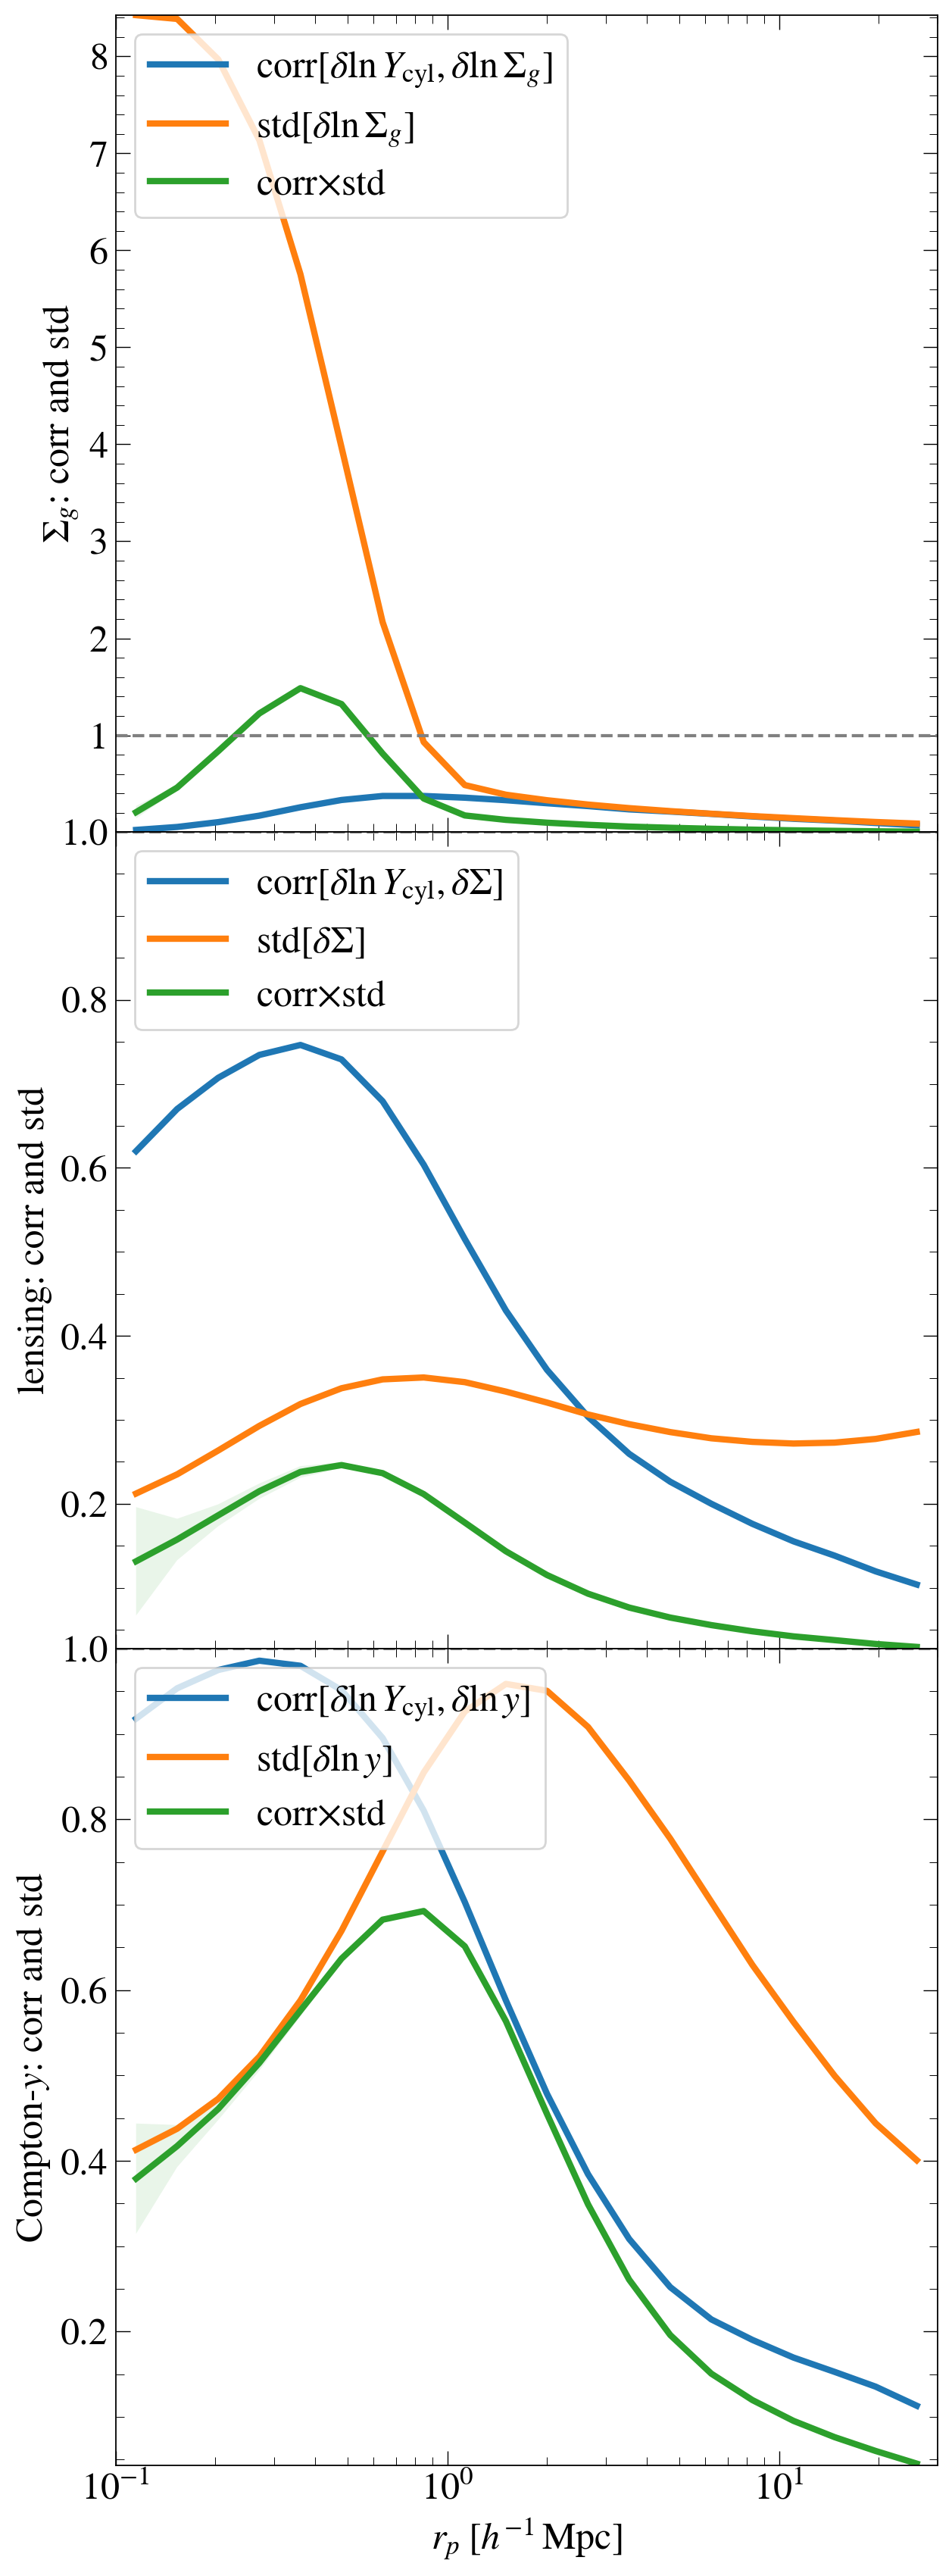

In [6]:
# using Ycyl (no noise) only
### use all the halos you have, without binning

fig, axes = plt.subplots(
    3, 1,
    sharex=True,
    figsize=(7, 21),
    gridspec_kw={'hspace': 0}
)

row_ylabels = [
    r"$\Sigma_g$: corr and std",
    r"lensing: corr and std",
    r"Compton-$y$: corr and std",
]


for row, ylabel in enumerate(row_ylabels):
    axes[row].set_ylabel(ylabel)

for col in range(4):
    axes[2].set_xlabel(r"$r_p \; [h^{-1}\,\mathrm{Mpc}]$")



for row in range(3):


    ax = axes[row]
    if row == 0:  # galaxy distribution
        
        ### TODO: placeholder
        rp = rp_bins_lnYsigg       # np.geomspace(0.1, 30)
        corr = mean_corrcoef_lnY_lnsigg     # 0.2*rp+1 
        corr_err = std_corrcoef_lnY_lnsigg # 0.05
        scatt = scat_lnsigg_hd_mean    # 0.4*rp+1 
        scatt_err = scat_lnsigg_hd_err # 0.05

        corr_scatt_err = np.sqrt((corr_err/corr)**2 + (scatt_err/scatt)**2) # error propagation formula
        
        line = ax.plot(rp, corr, lw=3, label=r"corr$[\delta\ln Y_{\rm cyl} , \delta \ln \Sigma_g]$")
        ax.fill_between(rp, corr-corr_err, corr+corr_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

        line = ax.plot(rp, scatt, lw=3, label=r"std$[\delta \ln \Sigma_g]$")
        ax.fill_between(rp, scatt-scatt_err, scatt+scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
        
        line = ax.plot(rp, corr*scatt, lw=3, label=r"corr$\times$std")
        ax.fill_between(rp, corr*scatt+corr_scatt_err, corr*scatt-corr_scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
        
        
    if row == 1:  # lensing
        ## TODO: same for lensing with d=300

        rp = rp_bins_Y500c_Sig  
        corr = mean_corrcoef_lnY_lnSig
        corr_err = std_corrcoef_lnY_lnSig
        scatt = scat_lnSig_mean    
        scatt_err = scat_lnSig_err 
        
        line = ax.plot(rp, corr, lw=3, label=r"corr$[\delta\ln Y_{\rm cyl} , \delta \Sigma]$")
        ax.fill_between(rp, corr-corr_err, corr+corr_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

        line = ax.plot(rp, scatt, lw=3, label=r"std$[\delta \Sigma]$")
        ax.fill_between(rp, scatt-scatt_err, scatt+scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
        
        line = ax.plot(rp, corr*scatt, lw=3, label=r"corr$\times$std")
        ax.fill_between(rp, corr*scatt+corr_scatt_err, corr*scatt-corr_scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

    
    if row == 2:  # SZ            
        ## TODO: same for y with d=300 (no noise)

        rp = rp_bins_lnY_lncy  
        corr = mean_corrcoef_lnY_lncy
        corr_err = std_corrcoef_lnY_lncy
        scatt = scat_lny_mean
        scatt_err = scat_lny_err
        
        line = ax.plot(rp, corr, lw=3, label=r"corr$[\delta\ln Y_{\rm cyl} , \delta\ln y]$")
        ax.fill_between(rp, corr-corr_err, corr+corr_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

        line = ax.plot(rp, scatt, lw=3, label=r"std$[\delta\ln y]$")
        ax.fill_between(rp, scatt-scatt_err, scatt+scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
        
        line = ax.plot(rp, corr*scatt, lw=3, label=r"corr$\times$std")
        ax.fill_between(rp, corr*scatt+corr_scatt_err, corr*scatt-corr_scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

    
    ax.axhline(1, c='gray', ls='--')
    # ax.set_ylim(0.9, 1.5)
    ax.set_xlim(0.1, 30)
    ax.set_xscale('log')        
    
    ax.legend(loc=2)
    ax.grid(False)
# plt.savefig('../plots/Y_correlation.pdf')